In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("train.csv")

In [4]:
df.head()

,policy_id,policy_tenure,age_of_car,age_of_policyholder,area_cluster,population_density,make,segment,model,fuel_type,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,is_claim
0,ID00001,0.515874,0.05,0.644231,C1,4990,1,A,M1,CNG,...,No,No,No,Yes,No,No,No,Yes,0,0
1,ID00002,0.672619,0.02,0.375000,C2,27003,1,A,M1,CNG,...,No,No,No,Yes,No,No,No,Yes,0,0
2,ID00003,0.841110,0.02,0.384615,C3,4076,1,A,M1,CNG,...,No,No,No,Yes,No,No,No,Yes,0,0
3,ID00004,0.900277,0.11,0.432692,C4,21622,1,C1,M2,Petrol,...,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,0
4,ID00005,0.596403,0.11,0.634615,C5,34738,2,A,M3,Petrol,...,No,Yes,Yes,Yes,No,Yes,Yes,Yes,2,0


In [5]:
df.columns

Index(['policy_id', 'policy_tenure', 'age_of_car', 'age_of_policyholder',
       'area_cluster', 'population_density', 'make', 'segment', 'model',
       'fuel_type', 'max_torque', 'max_power', 'engine_type', 'airbags',
       'is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors',
       'is_parking_camera', 'rear_brakes_type', 'displacement', 'cylinder',
       'transmission_type', 'gear_box', 'steering_type', 'turning_radius',
       'length', 'width', 'height', 'gross_weight', 'is_front_fog_lights',
       'is_rear_window_wiper', 'is_rear_window_washer',
       'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks',
       'is_central_locking', 'is_power_steering',
       'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror',
       'is_ecw', 'is_speed_alert', 'ncap_rating', 'is_claim'],
      dtype='str')

In [7]:
df.shape

(58592, 44)

In [ ]:
#Bu veri seti, genellikle bir araç sigorta hasar tahmini (insurance claim prediction) projesinde kullanılan özellikleri içermektedir. 
#Temel amaç, poliçe ve araç bilgilerine dayanarak müşterinin hasar kaydı oluşturup oluşturmayacağını (is_claim) tahmin etmektir.
"""policy_id: Poliçeye ait benzersiz kimlik numarası.
policy_tenure: Poliçenin süresi veya geçerlilik zamanı.
age_of_policyholder: Sigorta yaptıran kişinin yaşı.
area_cluster: Sigortalının ikamet ettiği bölge grubu (örneğin: Şehir merkezi, kırsal vb.).
population_density: Sigortalının yaşadığı bölgedeki nüfus yoğunluğu.
age_of_car: Aracın yaşı.
make: Araç markası (kodlanmış veya isim olarak).
segment: Aracın sınıfı (A segmenti, B segmenti, SUV vb.).
model: Aracın modeli.
length / width / height: Aracın uzunluğu, genişliği ve yüksekliği (mm cinsinden).
gross_weight: Aracın toplam brüt ağırlığı.
fuel_type: Yakıt türü (Benzin, Dizel, CNG).
engine_type: Motorun tipi (örneğin: K10C, i-VTEC).
displacement: Motor hacmi (cc - santimetreküp).
cylinder: Motordaki silindir sayısı.
max_torque: Maksimum tork gücü (Nm @ RPM).
max_power: Maksimum beygir gücü (bhp @ RPM).
transmission_type: Şanzıman tipi (Manuel veya Otomatik).
gear_box: Vites sayısı.
steering_type: Direksiyon tipi (Elektrikli, Hidrolik vb.).
turning_radius: Aracın dönüş yarıçapı.
rear_brakes_type: Arka fren tipi (Disk veya Kampana).
airbags: Araçtaki hava yastığı sayısı.
is_esc: Elektronik Stabilite Kontrolü var mı?
is_tpms: Lastik Basınç Takip Sistemi var mı?
is_brake_assist: Fren asistanı var mı?
is_parking_sensors / is_parking_camera: Park sensörü veya kamerası var mı?
is_adjustable_steering: Ayarlanabilir direksiyon var mı?
ncap_rating: Aracın güvenlik testi (NCAP) yıldız puanı.
is_front_fog_lights: Ön sis farları var mı?
is_rear_window_wiper / washer / defogger: Arka cam sileceği, yıkayıcısı veya buğu çözücüsü var mı?
is_power_door_locks / is_central_locking: Elektrikli kapı kilitleri veya merkezi kilit sistemi var mı?
is_speed_alert: Hız uyarı sistemi var mı?
is_ecw: Motor kontrol uyarısı veya benzeri bir elektronik uyarı sistemi.

is_claim: Hasar talebi durumu.
1: Sigortalı hasar kaydı oluşturmuş.
0: Sigortalı hasar kaydı oluşturmamış.
"""

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 58592 entries, 0 to 58591
Data columns (total 44 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   policy_id                         58592 non-null  str    
 1   policy_tenure                     58592 non-null  float64
 2   age_of_car                        58592 non-null  float64
 3   age_of_policyholder               58592 non-null  float64
 4   area_cluster                      58592 non-null  str    
 5   population_density                58592 non-null  int64  
 6   make                              58592 non-null  int64  
 7   segment                           58592 non-null  str    
 8   model                             58592 non-null  str    
 9   fuel_type                         58592 non-null  str    
 10  max_torque                        58592 non-null  str    
 11  max_power                         58592 non-null  str    
 12  engine_type    

In [9]:
df.describe()

,policy_tenure,age_of_car,age_of_policyholder,population_density,make,airbags,displacement,cylinder,gear_box,turning_radius,length,width,height,gross_weight,ncap_rating,is_claim
count,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.00000,58592.000000,58592.000000,58592.000000
mean,0.611246,0.069424,0.469420,18826.858667,1.763722,3.137066,1162.355851,3.626963,5.245443,4.852893,3850.476891,1672.233667,1553.33537,1385.276813,1.759950,0.063968
std,0.414156,0.056721,0.122886,17660.174792,1.136988,1.832641,266.304786,0.483616,0.430353,0.228061,311.457119,112.089135,79.62227,212.423085,1.389576,0.244698
min,0.002735,0.000000,0.288462,290.000000,1.000000,1.000000,796.000000,3.000000,5.000000,4.500000,3445.000000,1475.000000,1475.00000,1051.000000,0.000000,0.000000
25%,0.210250,0.020000,0.365385,6112.000000,1.000000,2.000000,796.000000,3.000000,5.000000,4.600000,3445.000000,1515.000000,1475.00000,1185.000000,0.000000,0.000000
50%,0.573792,0.060000,0.451923,8794.000000,1.000000,2.000000,1197.000000,4.000000,5.000000,4.800000,3845.000000,1735.000000,1530.00000,1335.000000,2.000000,0.000000
75%,1.039104,0.110000,0.548077,27003.000000,3.000000,6.000000,1493.000000,4.000000,5.000000,5.000000,3995.000000,1755.000000,1635.00000,1510.000000,3.000000,0.000000
max,1.396641,1.000000,1.000000,73430.000000,5.000000,6.000000,1498.000000,4.000000,6.000000,5.200000,4300.000000,1811.000000,1825.00000,1720.000000,5.000000,1.000000


In [10]:
df.drop("policy_id",axis=1,inplace=True)

In [25]:
df.isnull().sum()

policy_tenure                       0
age_of_car                          0
age_of_policyholder                 0
area_cluster                        0
population_density                  0
make                                0
segment                             0
model                               0
fuel_type                           0
max_torque                          0
max_power                           0
engine_type                         0
airbags                             0
is_esc                              0
is_adjustable_steering              0
is_tpms                             0
is_parking_sensors                  0
is_parking_camera                   0
rear_brakes_type                    0
displacement                        0
cylinder                            0
transmission_type                   0
gear_box                            0
steering_type                       0
turning_radius                      0
length                              0
width       

In [12]:
num_cols=df.select_dtypes(include=["int64","float64"])

In [13]:
cat_cols=df.select_dtypes(include=["object"])

C:\Users\ASUS\AppData\Local\Temp\ipykernel_7240\2465524231.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=df.select_dtypes(include=["object"])


In [34]:
num_cols

,policy_tenure,age_of_car,age_of_policyholder,population_density,make,airbags,displacement,cylinder,gear_box,turning_radius,length,width,height,gross_weight,ncap_rating,is_claim
0,0.515874,0.05,0.644231,4990,1,2,796,3,5,4.6,3445,1515,1475,1185,0,0
1,0.672619,0.02,0.375000,27003,1,2,796,3,5,4.6,3445,1515,1475,1185,0,0
2,0.841110,0.02,0.384615,4076,1,2,796,3,5,4.6,3445,1515,1475,1185,0,0
3,0.900277,0.11,0.432692,21622,1,2,1197,4,5,4.8,3995,1735,1515,1335,2,0
4,0.596403,0.11,0.634615,34738,2,2,999,3,5,5.0,3731,1579,1490,1155,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58587,0.355089,0.13,0.644231,8794,2,2,999,3,5,5.0,3731,1579,1490,1155,2,0
58588,1.199642,0.02,0.519231,7788,1,2,796,3,5,4.6,3445,1515,1475,1185,0,0
58589,1.162273,0.05,0.451923,34738,1,2,796,3,5,4.6,3445,1515,1475,1185,0,0
58590,1.236307,0.14,0.557692,8794,1,2,1197,4,5,4.8,3845,1735,1530,1335,2,0


In [19]:
cat_cols

,area_cluster,segment,model,fuel_type,max_torque,max_power,engine_type,is_esc,is_adjustable_steering,is_tpms,...,is_rear_window_washer,is_rear_window_defogger,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert
0,C1,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,No,No,No,...,No,No,No,No,No,Yes,No,No,No,Yes
1,C2,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,No,No,No,...,No,No,No,No,No,Yes,No,No,No,Yes
2,C3,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,No,No,No,...,No,No,No,No,No,Yes,No,No,No,Yes
3,C4,C1,M2,Petrol,113Nm@4400rpm,88.50bhp@6000rpm,1.2 L K12N Dualjet,Yes,Yes,No,...,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes
4,C5,A,M3,Petrol,91Nm@4250rpm,67.06bhp@5500rpm,1.0 SCe,No,No,No,...,No,No,No,Yes,Yes,Yes,No,Yes,Yes,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58587,C8,A,M3,Petrol,91Nm@4250rpm,67.06bhp@5500rpm,1.0 SCe,No,No,No,...,No,No,No,Yes,Yes,Yes,No,Yes,Yes,Yes
58588,C14,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,No,No,No,...,No,No,No,No,No,Yes,No,No,No,Yes
58589,C5,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,No,No,No,...,No,No,No,No,No,Yes,No,No,No,Yes
58590,C8,B2,M6,Petrol,113Nm@4400rpm,88.50bhp@6000rpm,K Series Dual jet,No,Yes,No,...,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes


In [20]:
import math

def plot_all_histograms(df, title_prefix=""):
    num_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for i, col in enumerate(num_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f"{title_prefix}{col}")
        plt.xlabel("")
        plt.ylabel("")

    plt.tight_layout()
    plt.show()



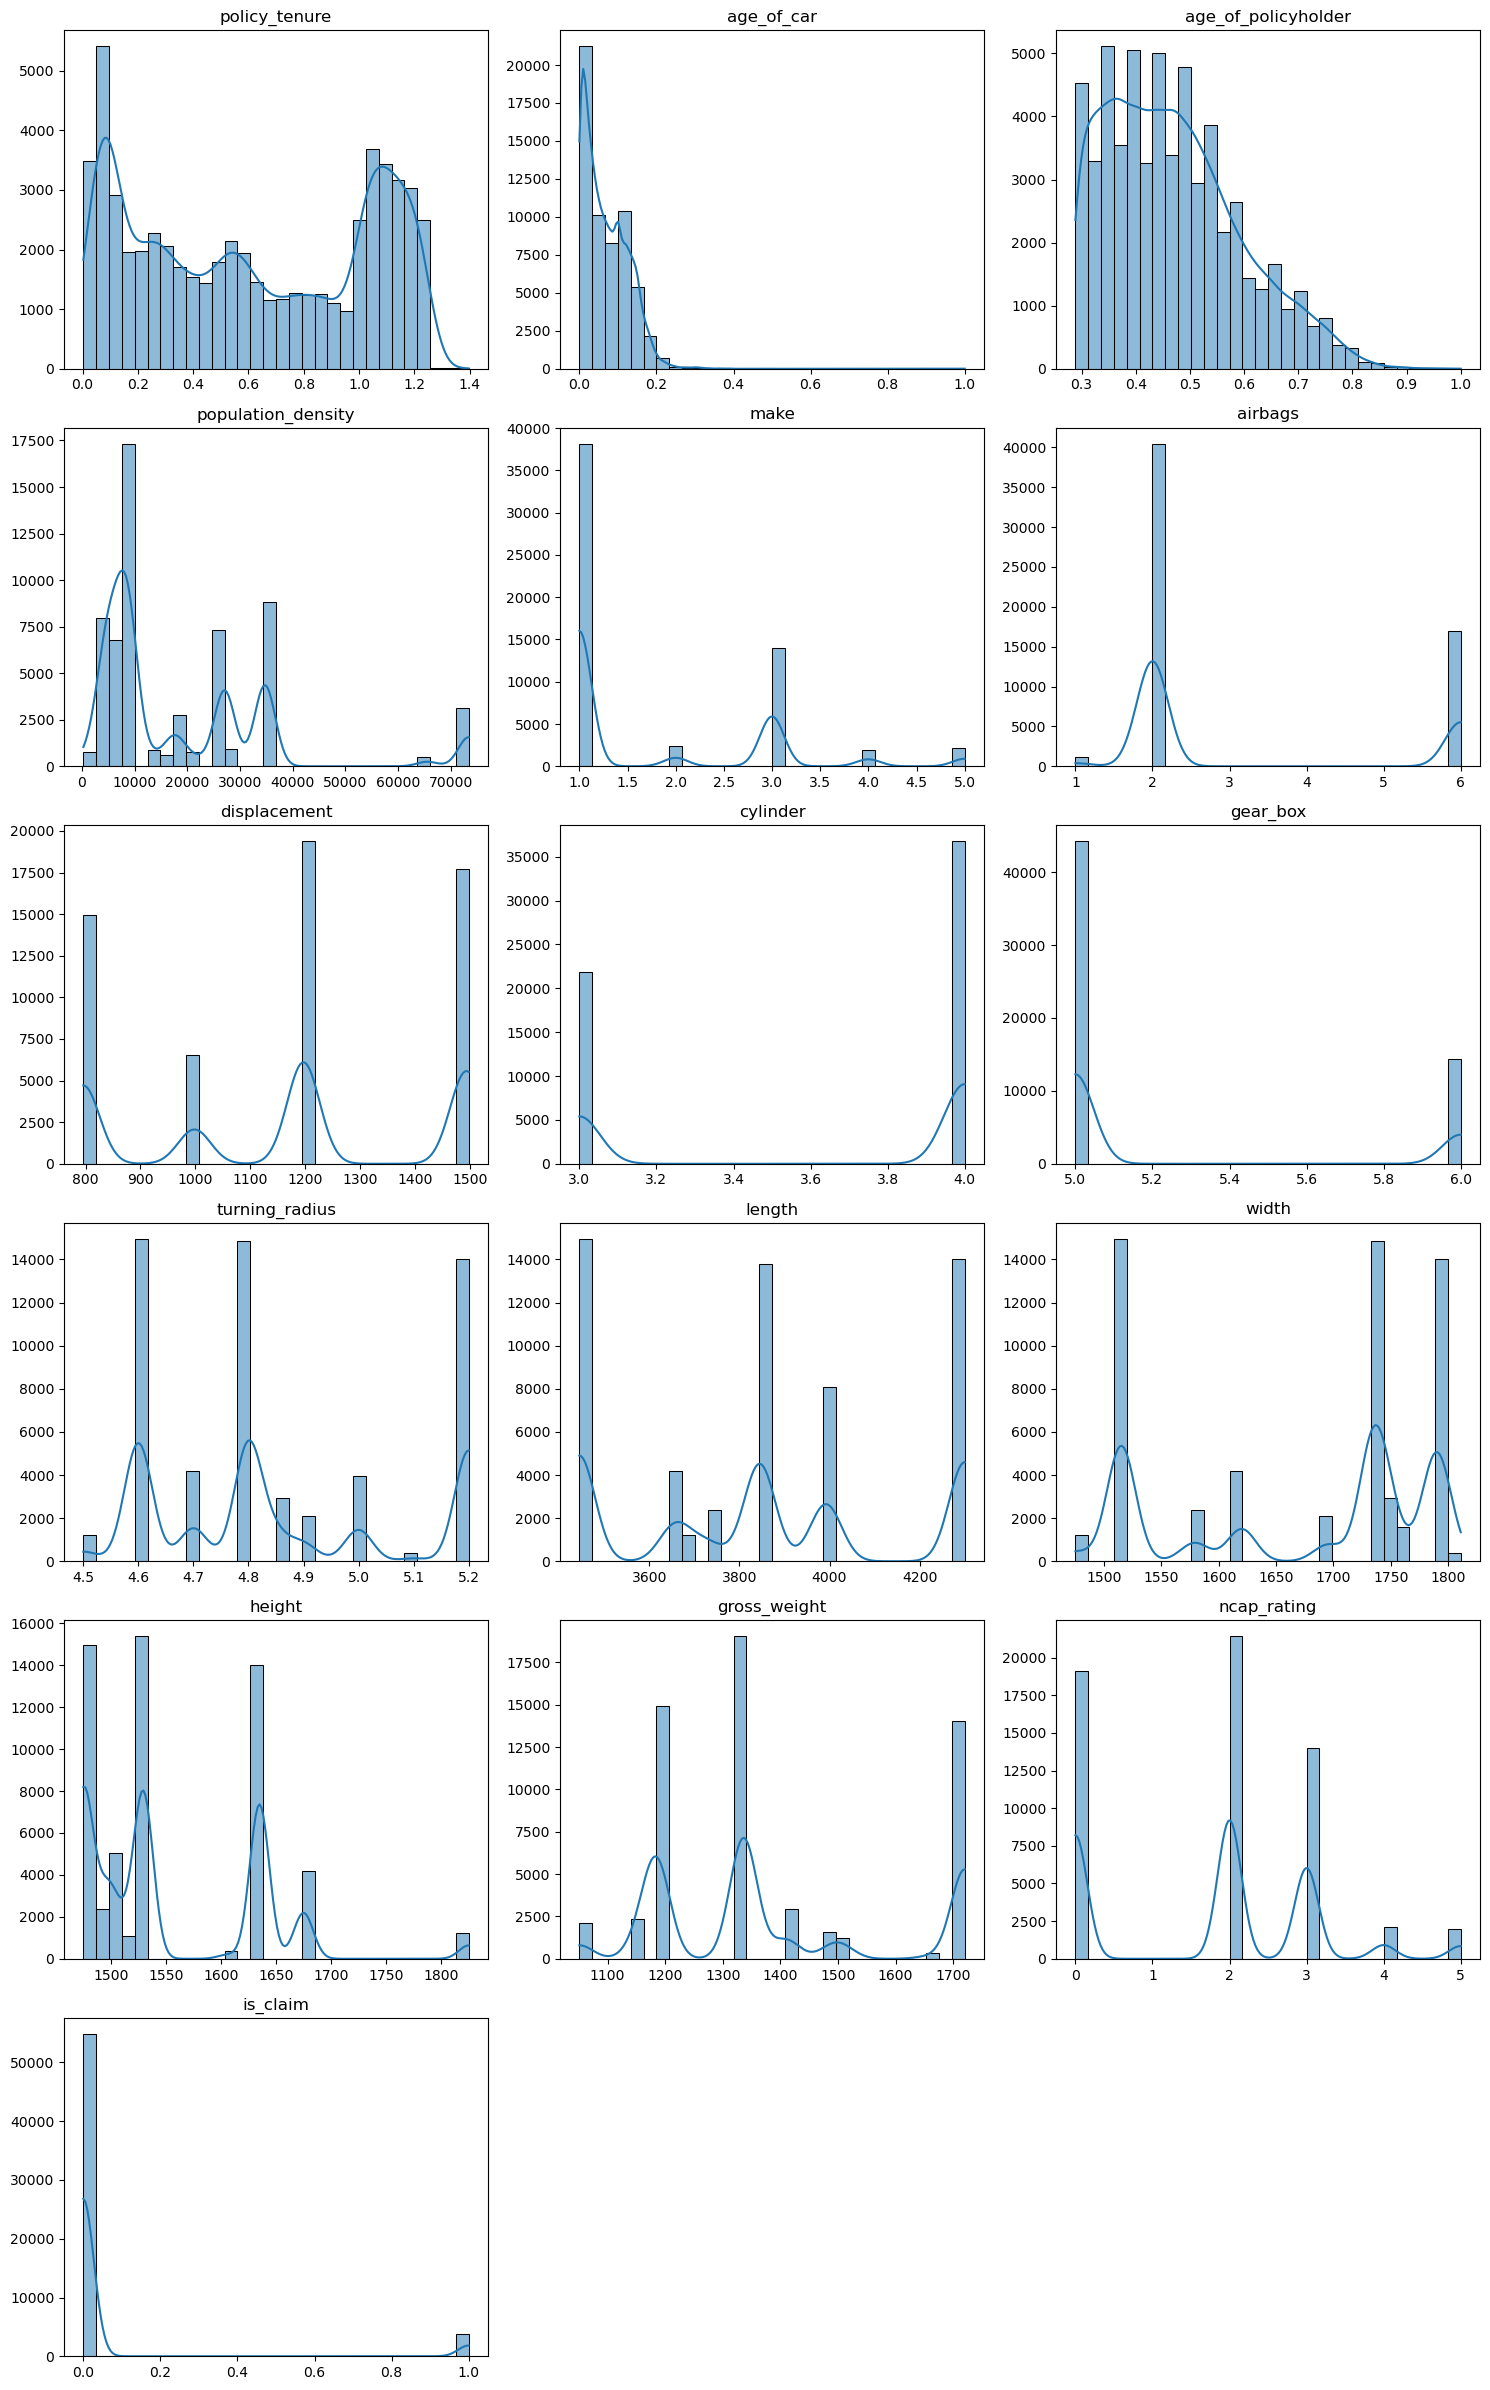

In [22]:
plot_all_histograms(df)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_7240\3451108321.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10,6))


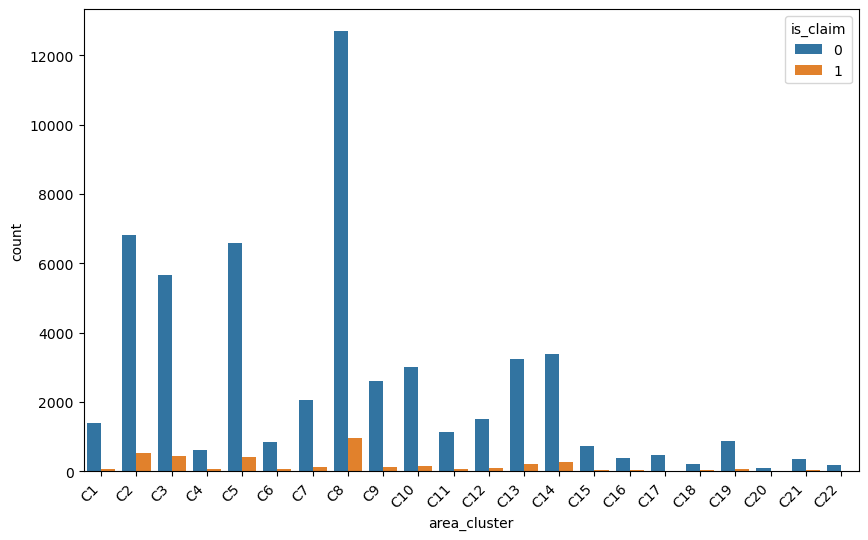

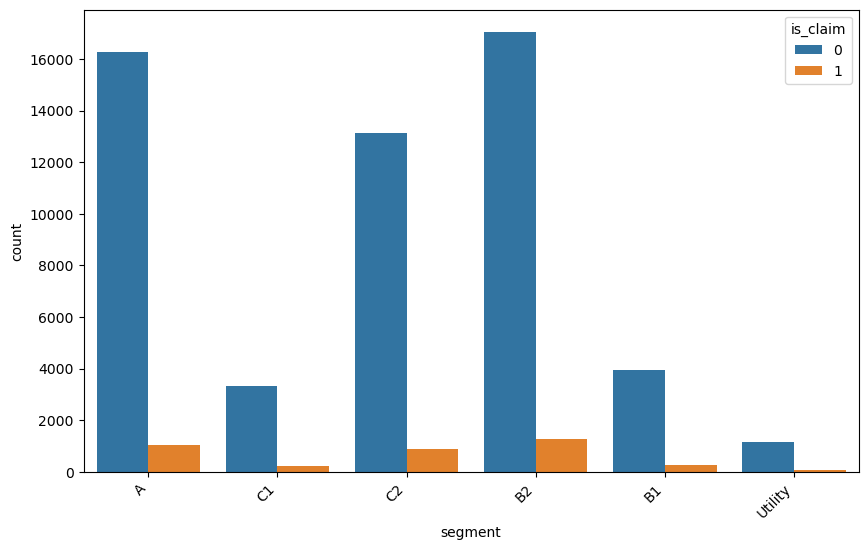

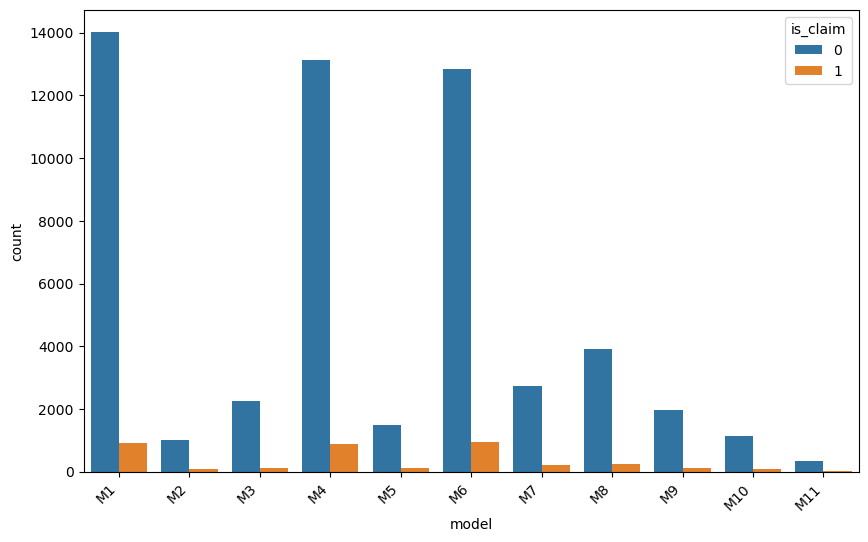

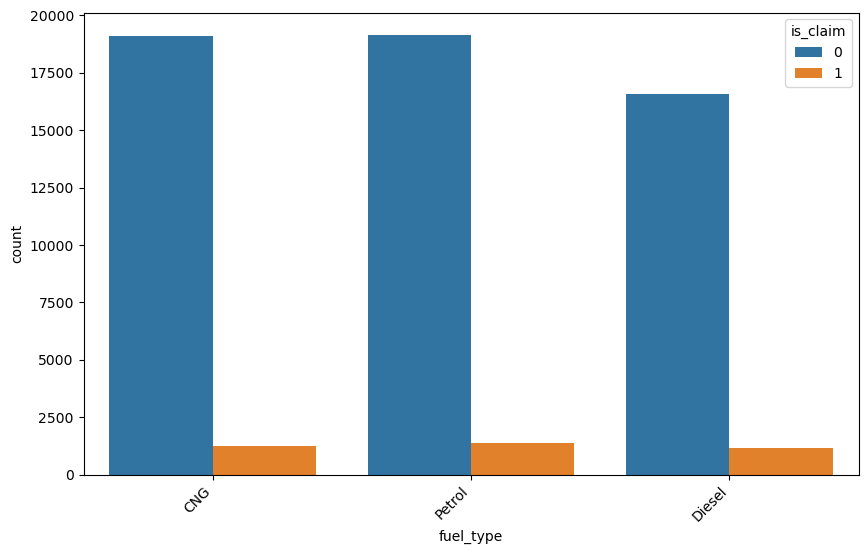

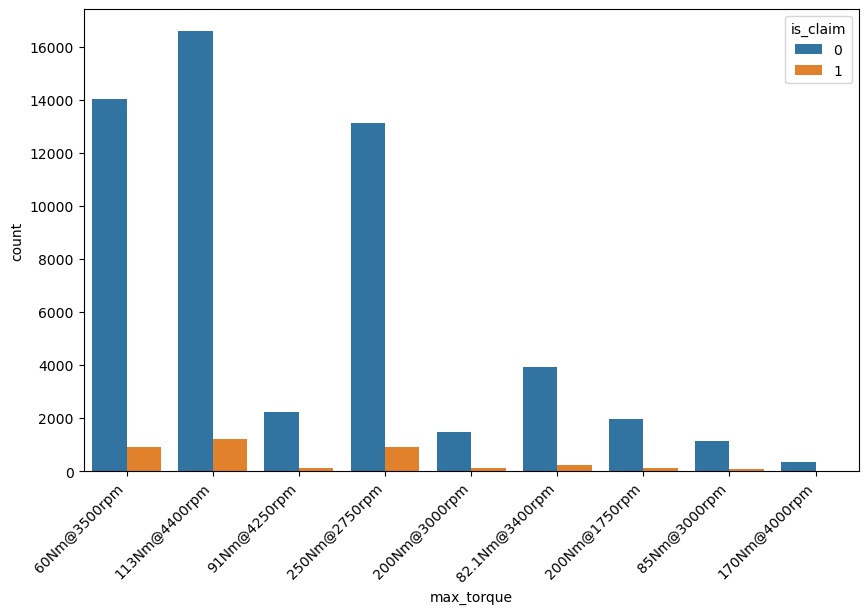

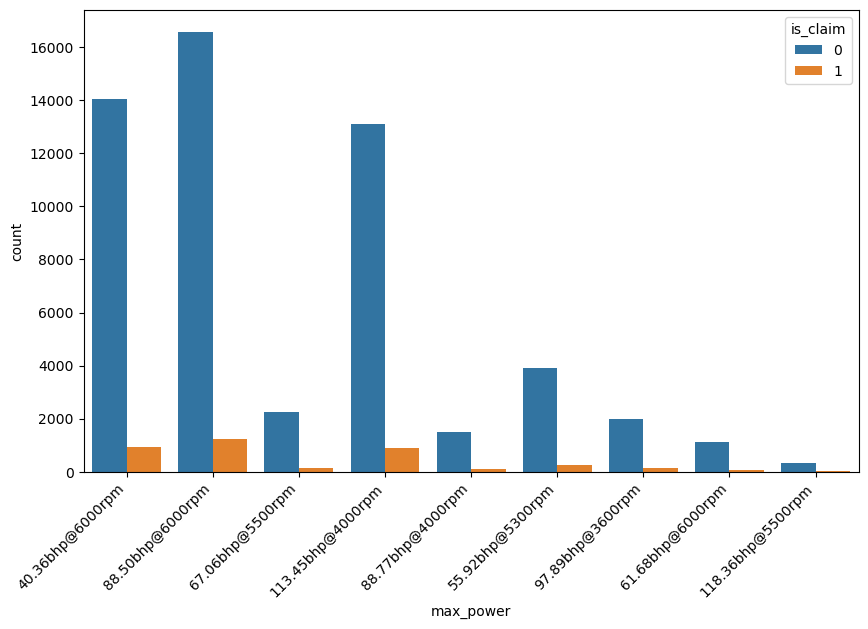

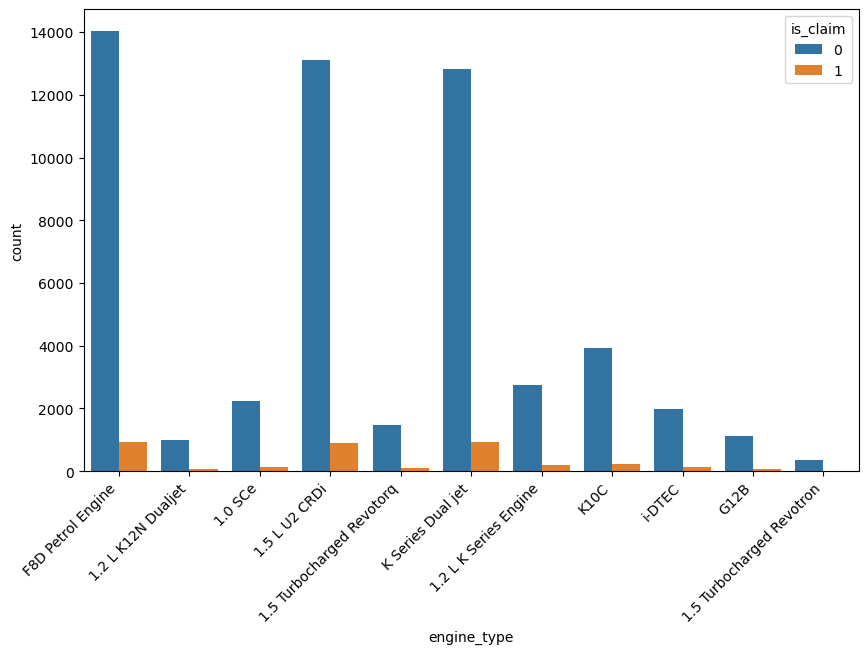

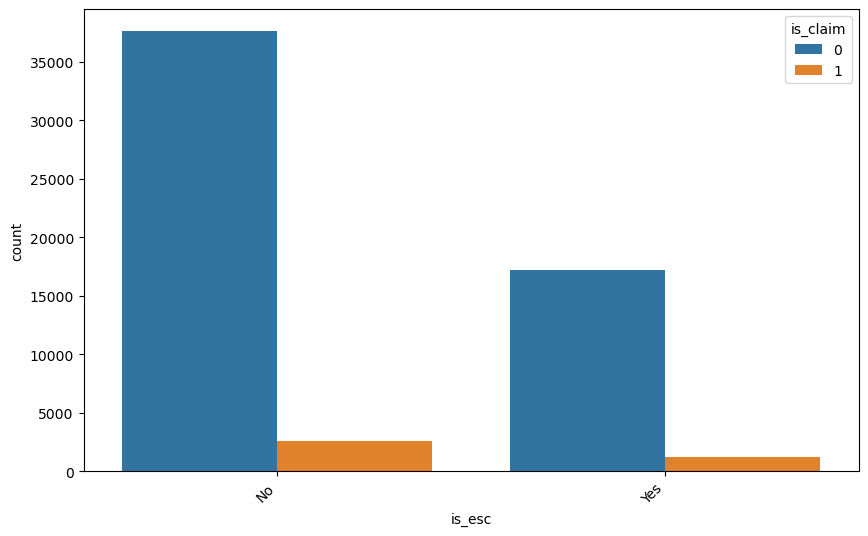

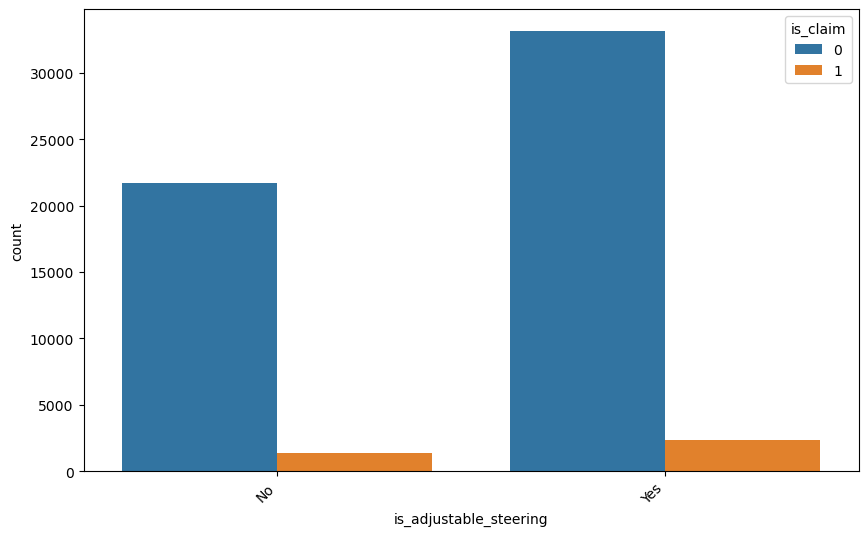

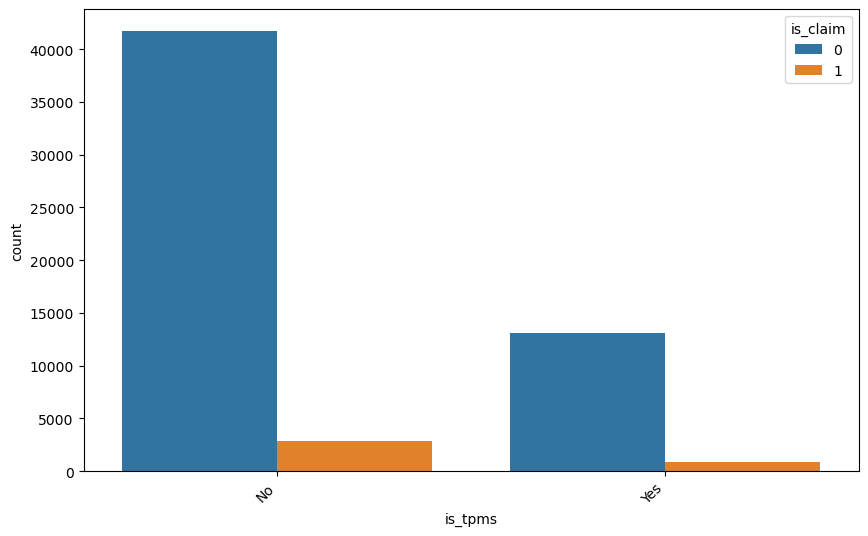

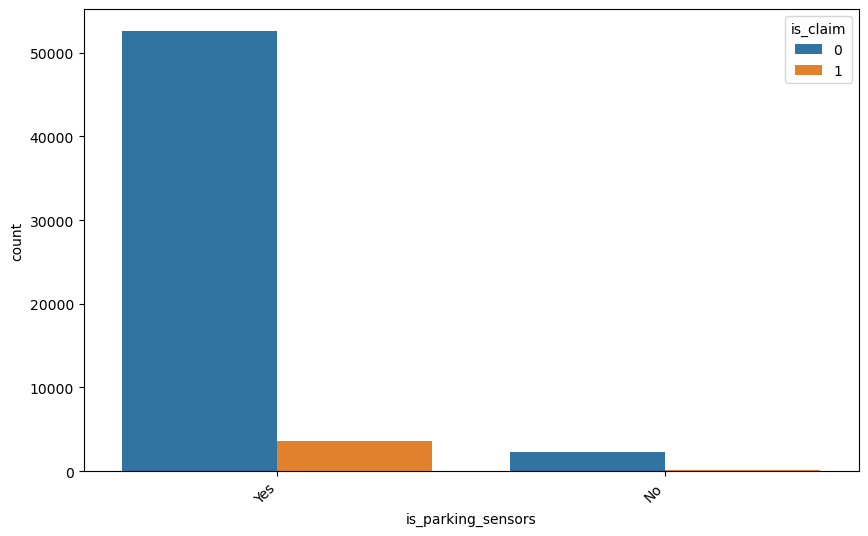

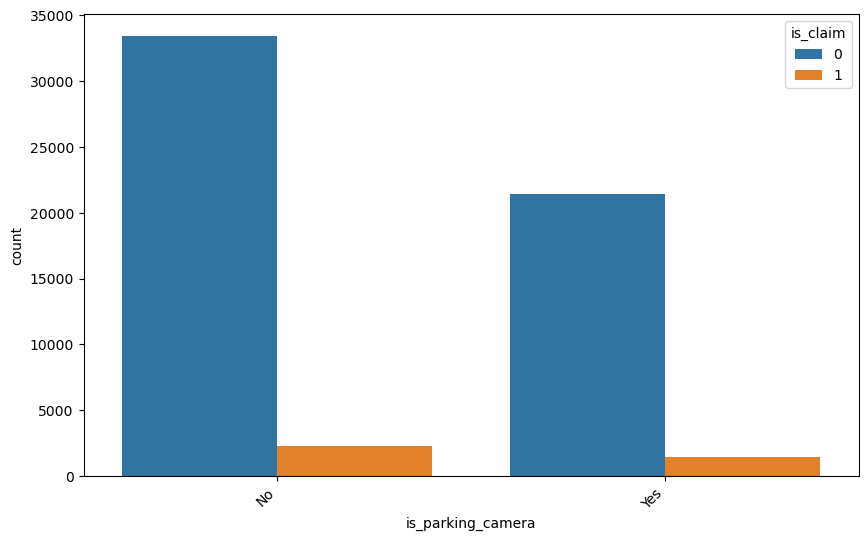

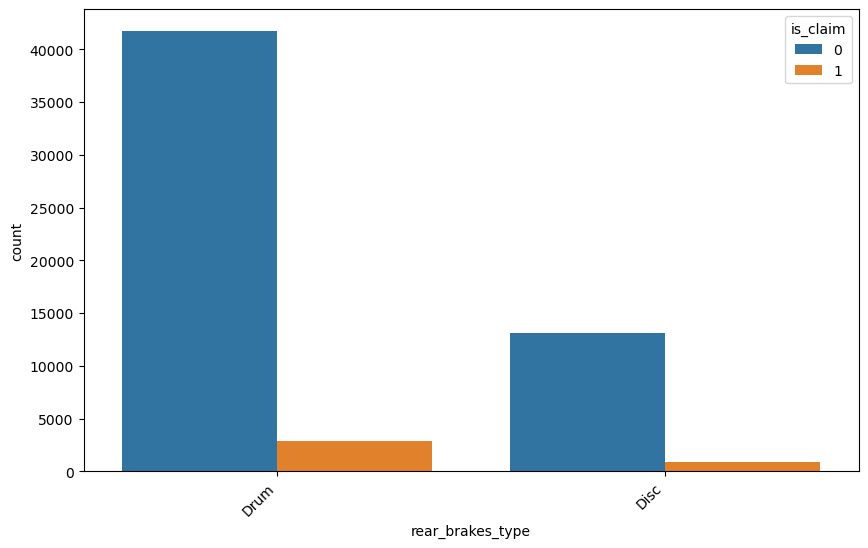

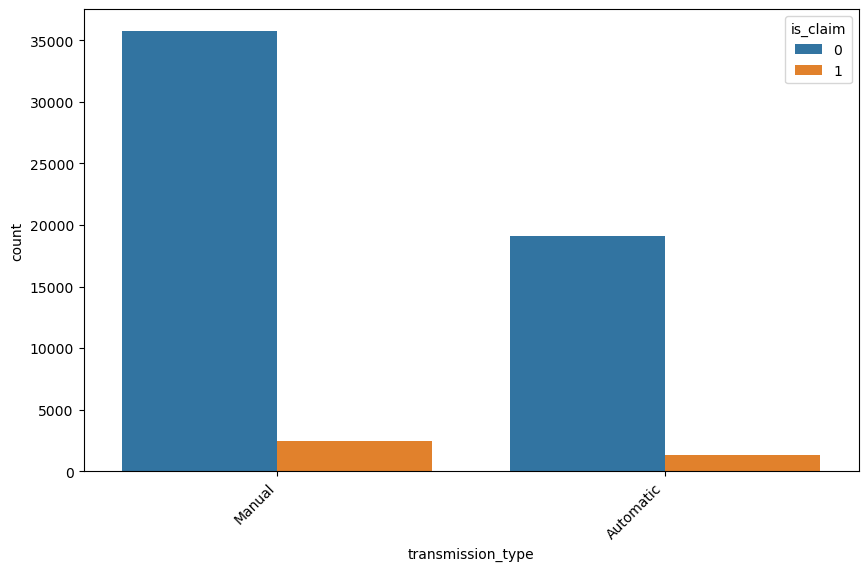

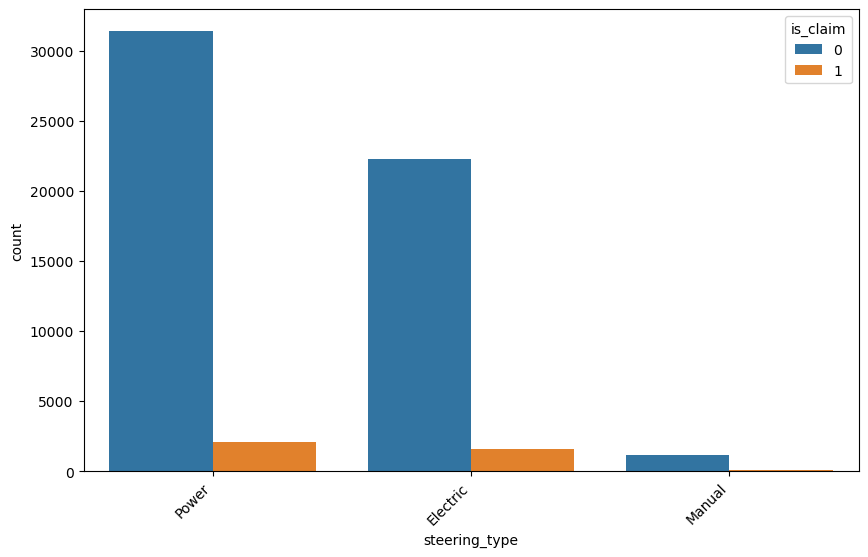

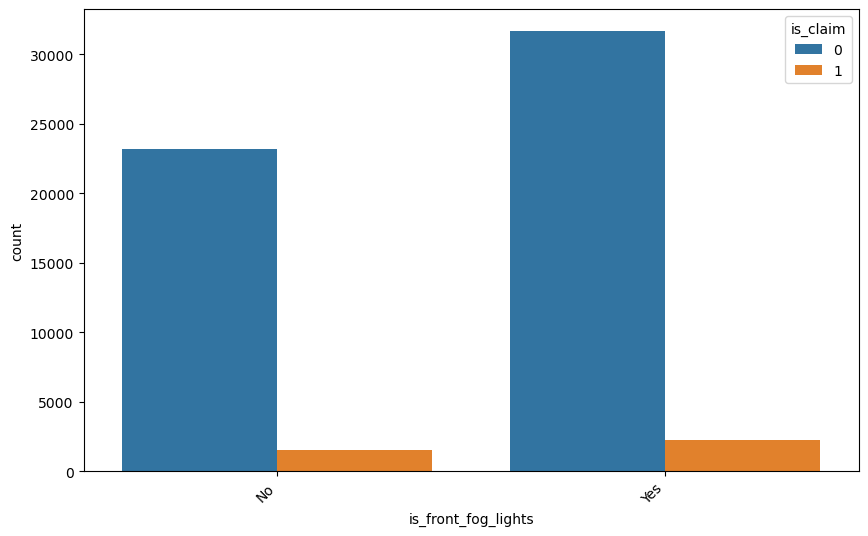

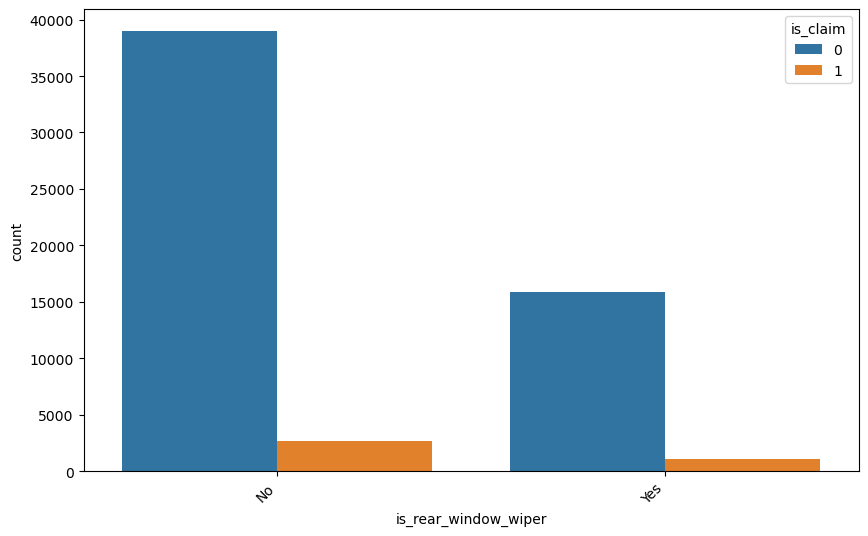

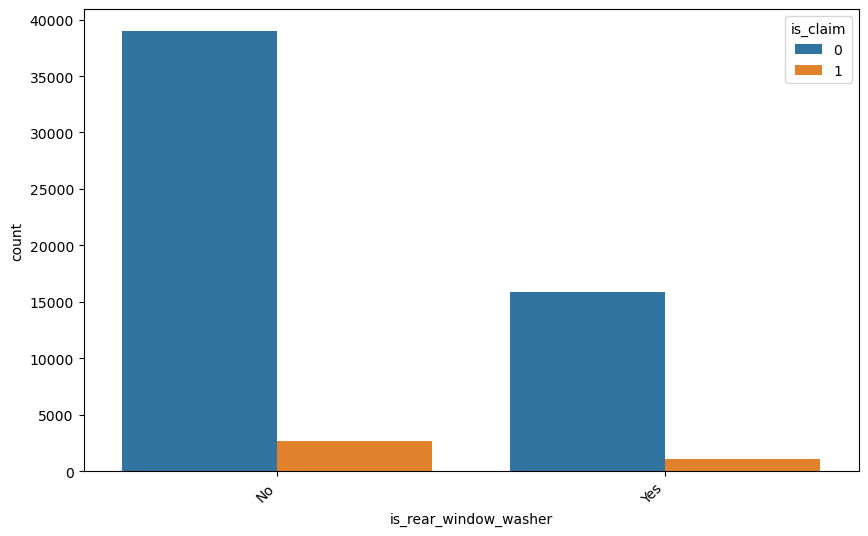

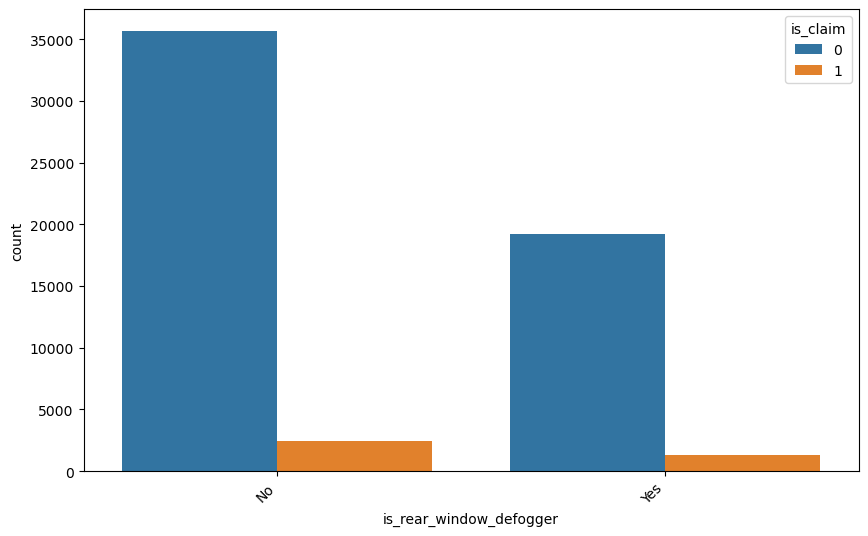

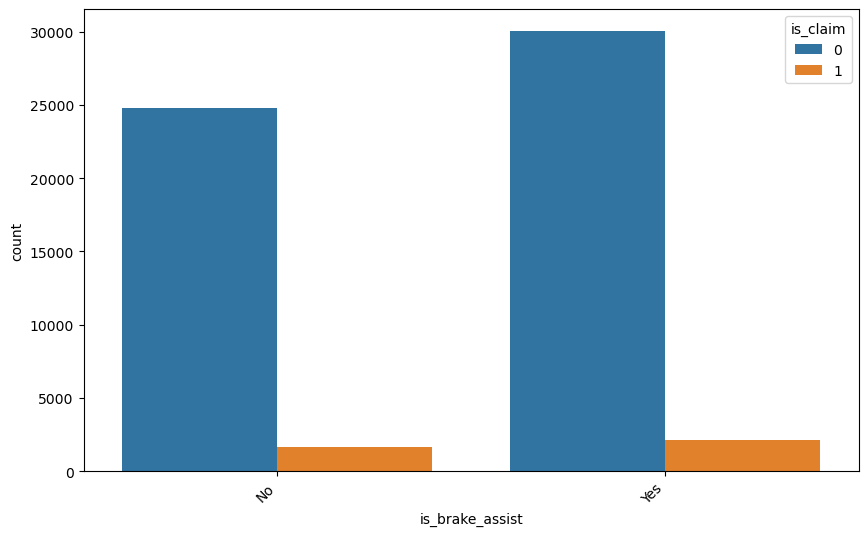

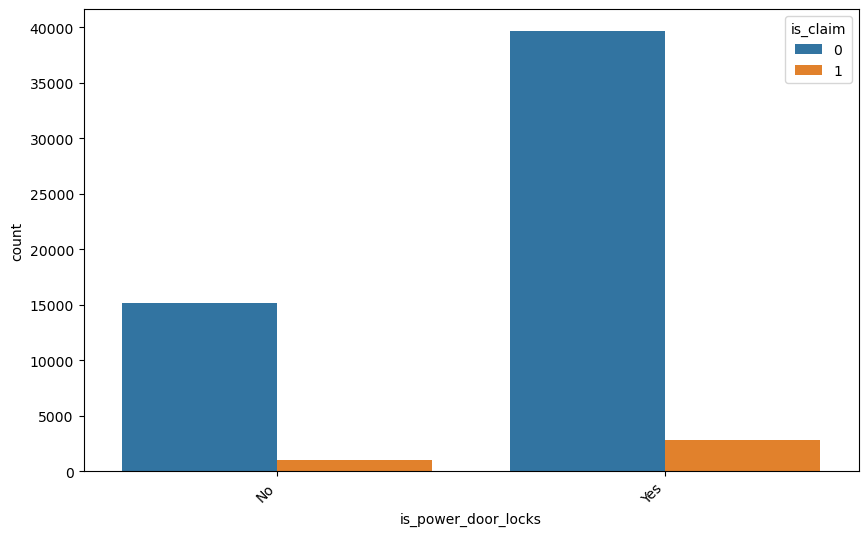

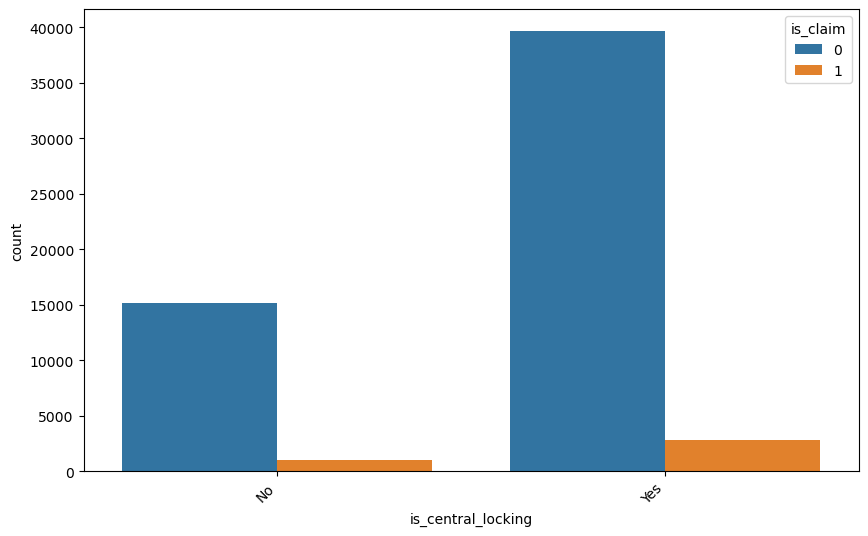

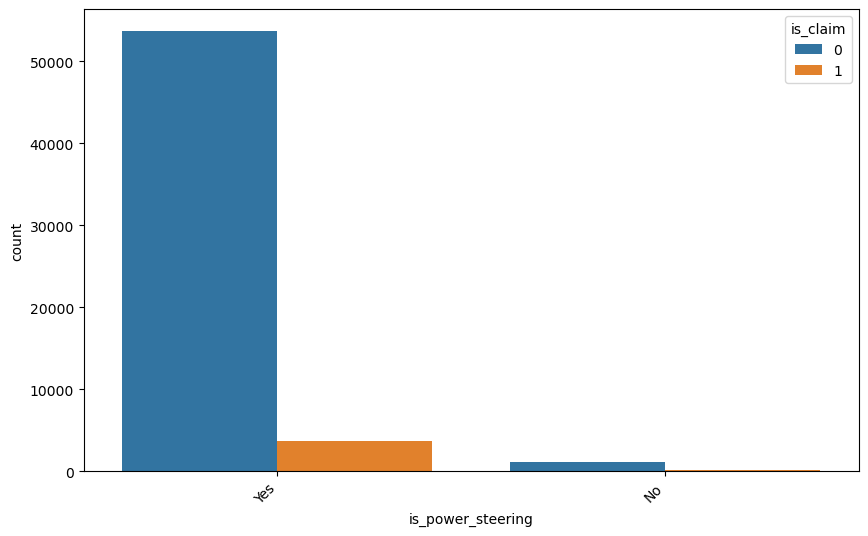

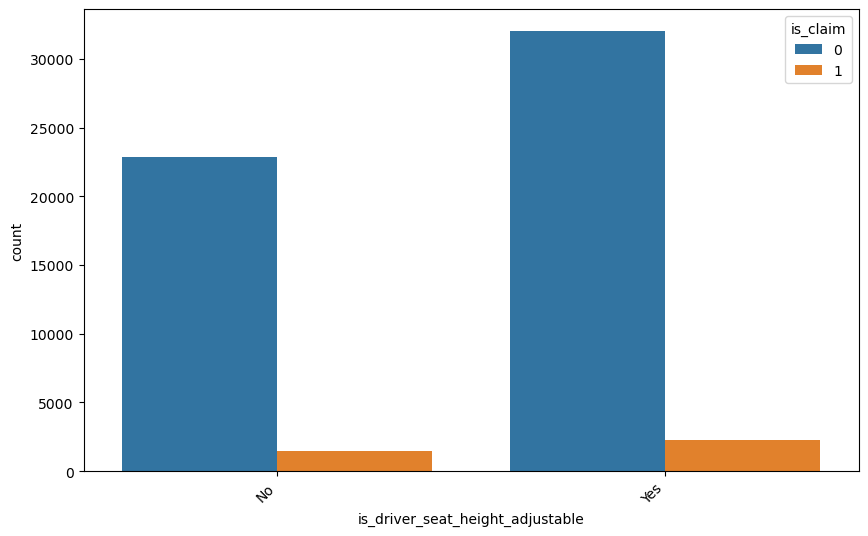

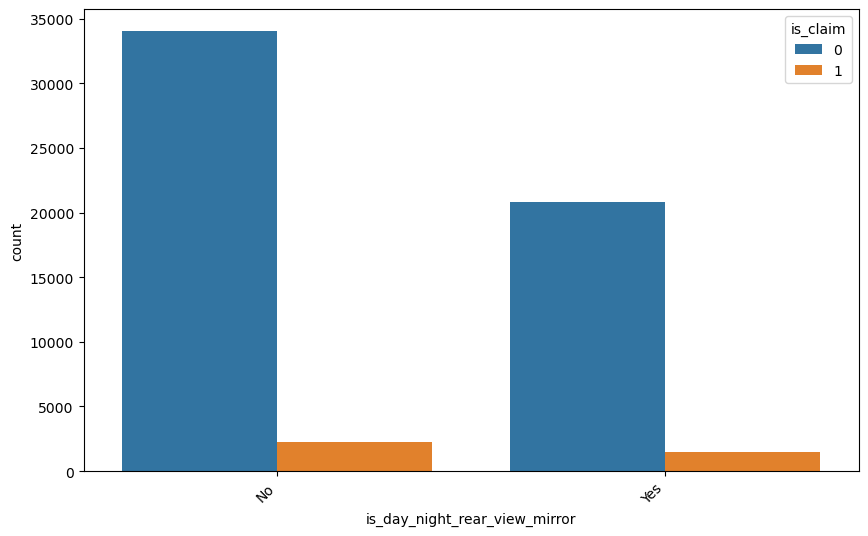

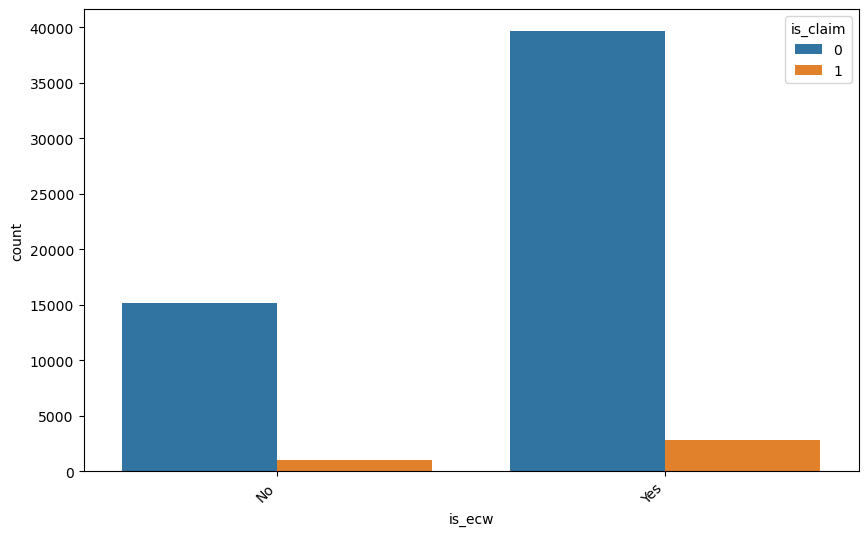

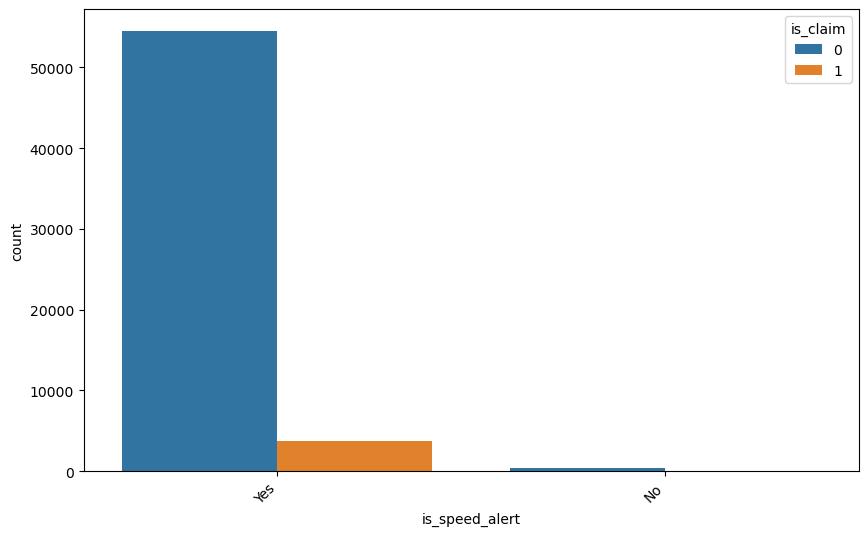

In [23]:
for col in cat_cols:
    plt.figure(figsize=(10,6))
    sns.countplot(    
        data=df,
        x=col,
        hue="is_claim"
    )
    plt.xticks(rotation=45,ha="right")
plt.show()

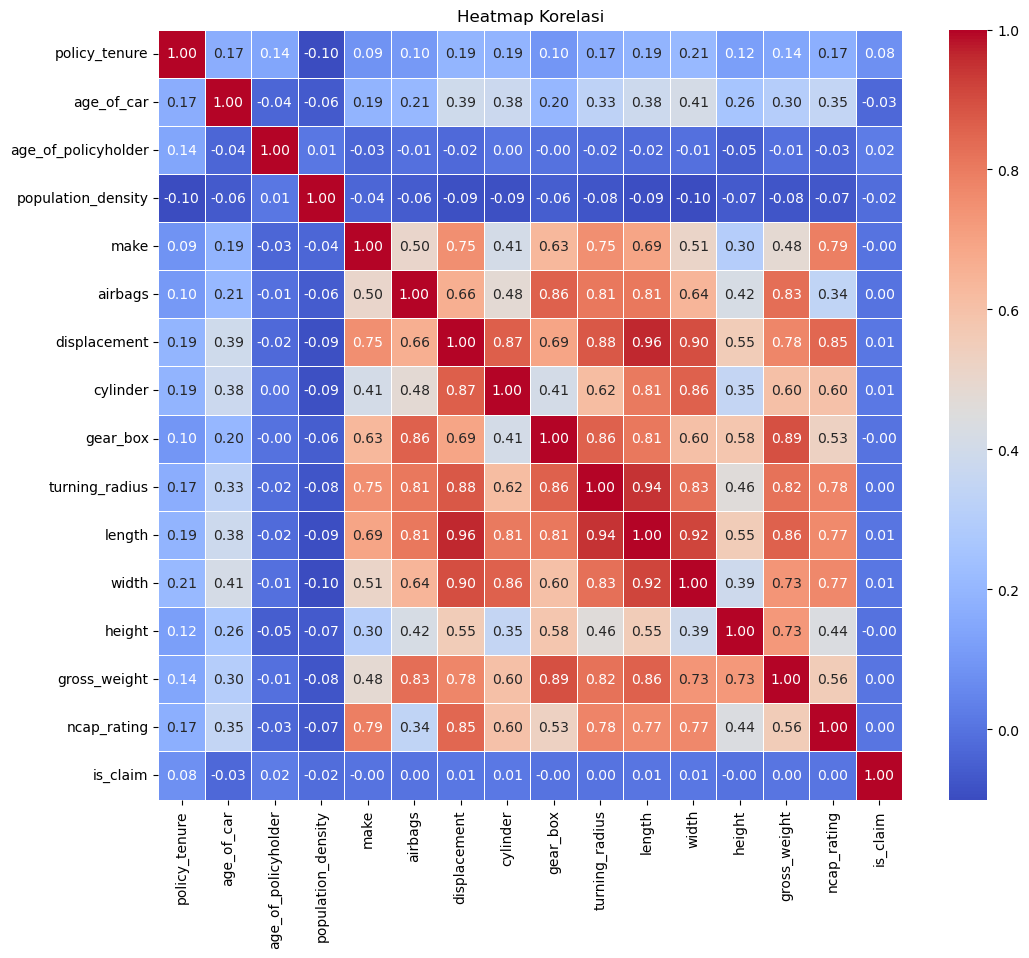

In [38]:
plt.figure(figsize=(12, 10))
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
correlation_matrix = df[num_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi')
plt.show()

In [41]:
def correlation_for_dropping(df,threshold):
    columns_to_drop=set()
    corr=df.corr(numeric_only=True).abs()
    for i in range(len(corr.columns)):
        for j in range(i):
            if (corr.iloc[i,j]>threshold):
                columns_to_drop.add(corr.columns[i])
    return columns_to_drop

In [42]:
correlation_for_dropping(df,0.85)

{'cylinder', 'gear_box', 'gross_weight', 'length', 'turning_radius', 'width'}

In [43]:
cols = [
    "cylinder",
    "gear_box",
    "gross_weight",
    "length",
    "turning_radius",
    "width",
    "is_claim"
]


df[cols].corr(
    numeric_only=True
)

,cylinder,gear_box,gross_weight,length,turning_radius,width,is_claim
cylinder,1.000000,0.410163,0.602978,0.805476,0.615806,0.862430,0.013434
gear_box,0.410163,1.000000,0.894639,0.808975,0.861740,0.601923,-0.000635
gross_weight,0.602978,0.894639,1.000000,0.861723,0.823097,0.734284,0.003894
length,0.805476,0.808975,0.861723,1.000000,0.944899,0.915918,0.006495
turning_radius,0.615806,0.861740,0.823097,0.944899,1.000000,0.825603,0.002724
width,0.862430,0.601923,0.734284,0.915918,0.825603,1.000000,0.009947
is_claim,0.013434,-0.000635,0.003894,0.006495,0.002724,0.009947,1.000000


In [44]:
df.drop(["width","turning_radius","gross_weight"],axis=1,inplace=True)

In [45]:
cat_cols["fuel_type"].value_counts()

fuel_type
Petrol    20532
CNG       20330
Diesel    17730
Name: count, dtype: int64

In [46]:
for col in cat_cols:
    print(cat_cols[col].value_counts())

area_cluster
C8     13654
C2      7342
C5      6979
C3      6101
C14     3660
C13     3423
C10     3155
C9      2734
C7      2167
C12     1589
C1      1468
C11     1212
C19      952
C6       890
C15      771
C4       665
C17      492
C16      401
C21      379
C18      242
C22      207
C20      109
Name: count, dtype: int64
segment
B2         18314
A          17321
C2         14018
B1          4173
C1          3557
Utility     1209
Name: count, dtype: int64
model
M1     14948
M4     14018
M6     13776
M8      4173
M7      2940
M3      2373
M9      2114
M5      1598
M10     1209
M2      1080
M11      363
Name: count, dtype: int64
fuel_type
Petrol    20532
CNG       20330
Diesel    17730
Name: count, dtype: int64
max_torque
113Nm@4400rpm     17796
60Nm@3500rpm      14948
250Nm@2750rpm     14018
82.1Nm@3400rpm     4173
91Nm@4250rpm       2373
200Nm@1750rpm      2114
200Nm@3000rpm      1598
85Nm@3000rpm       1209
170Nm@4000rpm       363
Name: count, dtype: int64
max_power
88.50bhp@6000rpm 

In [48]:
binary_cols = [
    "is_esc",
    "is_adjustable_steering",
    "is_tpms",
    "is_parking_sensors",
    "is_parking_camera",

    "is_front_fog_lights",
    "is_rear_window_wiper",
    "is_rear_window_washer",
    "is_rear_window_defogger",

    "is_brake_assist",
    "is_power_door_locks",
    "is_central_locking",
    "is_power_steering",

    "is_driver_seat_height_adjustable",
    "is_day_night_rear_view_mirror",

    "is_ecw",
    "is_speed_alert"
]

In [49]:
onehot_cols = [
    "area_cluster",
    "segment",
    "model",
    "fuel_type",
    "max_torque",
    "max_power",
    "engine_type",
    "rear_brakes_type",
    "transmission_type",
    "steering_type"
]

In [52]:
binary_categories=[
    ["No","Yes"]
]*len(binary_cols)

In [53]:
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.compose import ColumnTransformer

In [54]:
transformer=ColumnTransformer(
    transformers=[
        ("onehot",OneHotEncoder(
            drop="first",handle_unknown="ignore"
        ),onehot_cols),
        ("binary",OrdinalEncoder(categories=binary_categories
        ),binary_cols)
    ],remainder="passthrough"
)

In [69]:
def find_outliers_iqr(df, threshold = 1.5):
    outlier_summary = {}

    numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns
    #Kodun "tüm datasetlere uygulanabilir" olmasını sağlayan yer burasıdır.
    #Tablodaki metinleri (string/object) atlar ve sadece sayısal (int/float) sütunları listeler.
    
    for col in numeric_cols:
        #Kodun kalbi olan bu yöntem, veriyi küçükten büyüğe dizer ve 4 parçaya böler.
        #Q1 (%25'lik Dilim): Verinin ilk çeyreği.
        #Q3 (%75'lik Dilim): Verinin üçüncü çeyreği.
        #IQR: Bu iki değerin arasındaki farktır ($IQR = Q3 - Q1$).
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR
        #Burada "güvenli bölge" oluşturulur. Genellikle threshold (eşik) 1.5 olarak alınır.
        #Lower Bound: Alt sınır. Bunun altındakiler çok küçük uç değerlerdir.
        #Upper Bound: Üst sınır. Bunun üstündekiler çok büyük uç değerlerdir.
        

        outliers = df[ (df[col] < lower_bound) | (df[col] > upper_bound)]
        #altında ve üstünde kalanları outliers değişkenine ata.
        
        outlier_summary[col] = {
            "outlier_count" : outliers.shape[0],
            "outlier_percentage" : 100 * outliers.shape[0] / df.shape[0],
            "lower_bound" : lower_bound,
            "upper_bound" : upper_bound
        }
        #outlier_count: Kaç tane aykırı değer var?
        #outlier_percentage: Verinin yüzde kaçı aykırı? (Eğer %10'dan fazlaysa veride bir sorun olabilir).
        #Sınırlar: Hangi sayıdan sonrası "aykırı" kabul edildi?
    return pd.DataFrame(outlier_summary)

In [70]:
find_outliers_iqr(df, threshold = 1.5)

,policy_tenure,age_of_car,age_of_policyholder,population_density,make,airbags,displacement,cylinder,gear_box,length,height,ncap_rating,is_claim
outlier_count,0.000000,269.000000,221.000000,3647.000000,0.0,0.0,0.0,0.0,14381.000000,0.0,0.0,0.0,3748.000000
outlier_percentage,0.000000,0.459107,0.377185,6.224399,0.0,0.0,0.0,0.0,24.544306,0.0,0.0,0.0,6.396778
lower_bound,-1.033032,-0.115000,0.091346,-25224.500000,-2.0,-4.0,-249.5,1.5,5.000000,2620.0,1235.0,-4.5,0.000000
upper_bound,2.282386,0.245000,0.822115,58339.500000,6.0,12.0,2538.5,5.5,5.000000,4820.0,1875.0,7.5,0.000000


In [61]:
X=df.drop("is_claim",axis=1)
y=df["is_claim"]

In [62]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.35,random_state=42)

In [63]:
X_train=transformer.fit_transform(X_train)
X_test=transformer.transform(X_test)

In [64]:
encoded_cols=transformer.get_feature_names_out()

In [65]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [66]:
X_train=pd.DataFrame(X_train,columns=encoded_cols)
X_test=pd.DataFrame(X_test,columns=encoded_cols)

In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from xgboost import XGBClassifier


models = {
    "Logistic Regression":
        LogisticRegression(
            max_iter=1000,
            random_state=42),
    "KNN":
        KNeighborsClassifier(),
    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42),

    "Random Forest":
        RandomForestClassifier(
            random_state=42),

    "AdaBoost":
        AdaBoostClassifier(
            random_state=42),

    "Gradient Boost":
        GradientBoostingClassifier(
            random_state=42),

    "XGBoost":
        XGBClassifier(
            random_state=42)
}

In [68]:
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score)


for name, model in models.items():

    model.fit(
        X_train,
        y_train
    )


    y_pred = model.predict(
        X_test
    )


    accuracy = accuracy_score(
        y_test,
        y_pred
    )


    recall = recall_score(
        y_test,
        y_pred
    )


    f1 = f1_score(
        y_test,
        y_pred
    )


    print(name)

    print(
        "Accuracy:",
        round(accuracy,3)
    )

    print(
        "Recall:",
        round(recall,3)
    )

    print(
        "F1:",
        round(f1,3)
    )

    print("-"*40)

Logistic Regression
Accuracy: 0.934
Recall: 0.0
F1: 0.0
----------------------------------------
KNN
Accuracy: 0.931
Recall: 0.004
F1: 0.008
----------------------------------------
Decision Tree
Accuracy: 0.875
Recall: 0.085
F1: 0.082
----------------------------------------
Random Forest
Accuracy: 0.93
Recall: 0.007
F1: 0.012
----------------------------------------


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoost
Accuracy: 0.934
Recall: 0.0
F1: 0.0
----------------------------------------
Gradient Boost
Accuracy: 0.934
Recall: 0.001
F1: 0.001
----------------------------------------
XGBoost
Accuracy: 0.933
Recall: 0.001
F1: 0.003
----------------------------------------


In [71]:
df["is_claim"].value_counts()

is_claim
0    54844
1     3748
Name: count, dtype: int64

In [72]:
df["is_claim"].value_counts(
    normalize=True
)

is_claim
0    0.936032
1    0.063968
Name: proportion, dtype: float64

In [77]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier


from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    roc_auc_score)


neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos


models = {
    "Logistic Regression":
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(),
    "Decision Tree":
        DecisionTreeClassifier(
            class_weight="balanced",
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            class_weight="balanced",
            random_state=42
        ),


    "AdaBoost":
        AdaBoostClassifier(
            random_state=42
        ),


    "Gradient Boost":
        GradientBoostingClassifier(
            random_state=42
        ),


    "XGBoost":
        XGBClassifier(
            scale_pos_weight=scale_pos_weight,
            random_state=42
        )
}


for name, model in models.items():
    model.fit(X_train,y_train)


    y_pred = model.predict(X_test)


    y_prob = model.predict_proba(
        X_test

    )[:,1]


    accuracy = accuracy_score(

        y_test,

        y_pred
    )


    recall = recall_score(

        y_test,

        y_pred
    )


    f1 = f1_score(

        y_test,

        y_pred
    )


    roc_auc = roc_auc_score(

        y_test,

        y_prob
    )


    print(name)

    print(

        "Accuracy:",

        round(accuracy,3)
    )


    print(

        "Recall:",

        round(recall,3)
    )


    print(

        "F1:",

        round(f1,3)
    )


    print(

        "ROC-AUC:",

        round(roc_auc,3)
    )


    print("-"*40)

Logistic Regression
Accuracy: 0.571
Recall: 0.578
F1: 0.151
ROC-AUC: 0.599
----------------------------------------
KNN
Accuracy: 0.931
Recall: 0.004
F1: 0.008
ROC-AUC: 0.531
----------------------------------------
Decision Tree
Accuracy: 0.877
Recall: 0.083
F1: 0.081
ROC-AUC: 0.508
----------------------------------------
Random Forest
Accuracy: 0.93
Recall: 0.009
F1: 0.017
ROC-AUC: 0.571
----------------------------------------


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoost
Accuracy: 0.934
Recall: 0.0
F1: 0.0
ROC-AUC: 0.632
----------------------------------------
Gradient Boost
Accuracy: 0.934
Recall: 0.001
F1: 0.001
ROC-AUC: 0.651
----------------------------------------
XGBoost
Accuracy: 0.698
Recall: 0.413
F1: 0.153
ROC-AUC: 0.6
----------------------------------------


In [78]:
best_model = GradientBoostingClassifier(
    random_state=42
)

best_model.fit(
    X_train,
    y_train
)

y_prob = best_model.predict_proba(
    X_test
)[:,1]

In [79]:
threshold = 0.2

y_pred = (
    y_prob >= threshold
).astype(int)

In [80]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

print(
    roc_auc_score(
        y_test,
        y_prob
    )
)

              precision    recall  f1-score   support

           0       0.93      1.00      0.96     19151
           1       0.13      0.00      0.01      1357

    accuracy                           0.93     20508
   macro avg       0.53      0.50      0.49     20508
weighted avg       0.88      0.93      0.90     20508

0.6508034871757853


In [81]:
from sklearn.metrics import (

    precision_score,

    recall_score,

    f1_score
)


thresholds = [

    0.5,

    0.3,

    0.2,

    0.1
]


for threshold in thresholds:

    y_pred = (

        y_prob >= threshold

    ).astype(int)


    precision = precision_score(

        y_test,

        y_pred
    )


    recall = recall_score(

        y_test,

        y_pred
    )


    f1 = f1_score(

        y_test,

        y_pred
    )


    print(

        f"Threshold: {threshold}"
    )


    print(

        "Precision:",

        round(precision,3)
    )


    print(

        "Recall:",

        round(recall,3)
    )


    print(

        "F1:",

        round(f1,3)
    )


    print("-"*30)

Threshold: 0.5
Precision: 0.2
Recall: 0.001
F1: 0.001
------------------------------
Threshold: 0.3
Precision: 0.048
Recall: 0.001
F1: 0.001
------------------------------
Threshold: 0.2
Precision: 0.13
Recall: 0.004
F1: 0.009
------------------------------
Threshold: 0.1
Precision: 0.116
Recall: 0.228
F1: 0.153
------------------------------


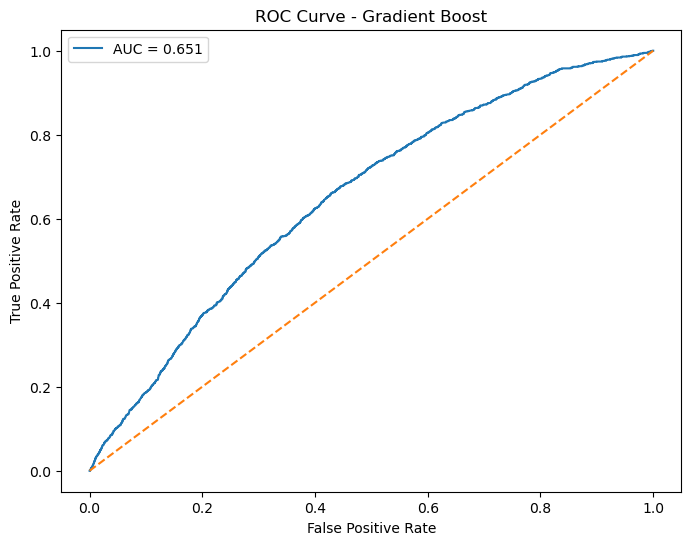

In [82]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

auc_score = roc_auc_score(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gradient Boost")
plt.legend()
plt.show()

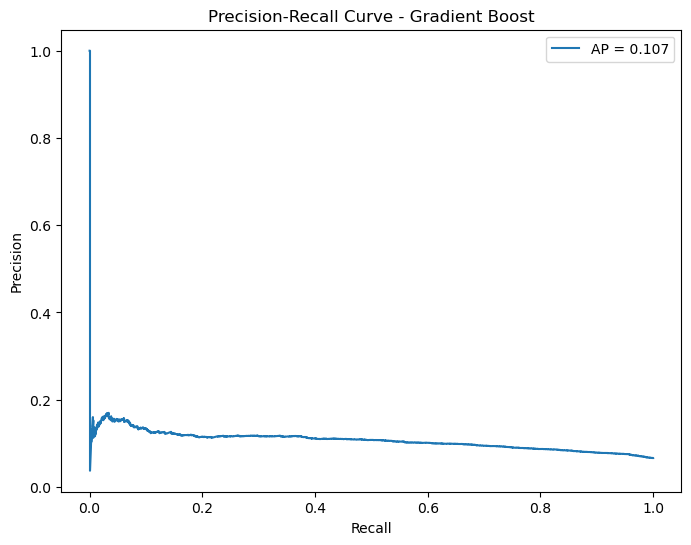

Average Precision: 0.10654099284976289


In [83]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

ap_score = average_precision_score(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision,
    label=f"AP = {ap_score:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Gradient Boost")
plt.legend()
plt.show()

print("Average Precision:", ap_score)